In [1]:
import pandas as pd
import numpy as np
import os
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import make_column_selector


## Modelo multivariable

In [2]:
df=pd.read_csv("metadata.csv")
df

,patientid,offset,sex,age,finding,survival,intubated,intubation_present,went_icu,in_icu,...,date,location,folder,filename,doi,url,license,clinical_notes,other_notes,Unnamed: 28
0,2,0.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 22, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-a-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,"On January 22, 2020, a 65-year-old man with a ...",NaN,NaN
1,2,3.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 25, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-b-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,"On January 22, 2020, a 65-year-old man with a ...",NaN,NaN
2,2,5.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 27, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-c-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,"On January 22, 2020, a 65-year-old man with a ...",NaN,NaN
3,2,6.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 28, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-d-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,"On January 22, 2020, a 65-year-old man with a ...",NaN,NaN
4,4,0.0,F,52.0,COVID-19,NaN,NaN,NaN,NaN,NaN,...,"January 25, 2020","Changhua Christian Hospital, Changhua City, Ta...",images,nejmc2001573_f1a.jpeg,10.1056/NEJMc2001573,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,diffuse infiltrates in the bilateral lower lungs,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,205,11.0,M,55.0,COVID-19,Y,NaN,Y,Y,Y,...,NaN,"North Derbyshire, UK",images,covid-19-pneumonia-progression-and-regression-...,NaN,https://radiopaedia.org/cases/covid-19-pneumon...,CC BY-NC-SA,"ITU admission, Endotracheal tube, nasogastric ...","Case courtesy of Dr Ian Bickle, Radiopaedia.or...",NaN
368,205,13.0,M,55.0,COVID-19,Y,NaN,Y,Y,Y,...,NaN,"North Derbyshire, UK",images,covid-19-pneumonia-progression-and-regression-...,NaN,https://radiopaedia.org/cases/covid-19-pneumon...,CC BY-NC-SA,Lines and tubes suitably sited. Minor regress...,"Case courtesy of Dr Ian Bickle, Radiopaedia.or...",NaN
369,205,20.0,M,55.0,COVID-19,Y,NaN,Y,Y,Y,...,NaN,"North Derbyshire, UK",images,covid-19-pneumonia-progression-and-regression-...,NaN,https://radiopaedia.org/cases/covid-19-pneumon...,CC BY-NC-SA,increasing oxygen requirements. Extubated. Po...,"Case courtesy of Dr Ian Bickle, Radiopaedia.or...",NaN
370,205,24.0,M,55.0,COVID-19,Y,NaN,N,Y,Y,...,NaN,"North Derbyshire, UK",images,covid-19-pneumonia-progression-and-regression-...,NaN,https://radiopaedia.org/cases/covid-19-pneumon...,CC BY-NC-SA,Extubated since the prior radiograph. Partial...,"Case courtesy of Dr Ian Bickle, Radiopaedia.or...",NaN


In [26]:
enfermedades = df["finding"].unique().tolist()
enfermedades


['COVID-19',
 'ARDS',
 'SARS',
 'Pneumocystis',
 'Streptococcus',
 'No Finding',
 'Chlamydophila',
 'E.Coli',
 'COVID-19, ARDS',
 'Klebsiella',
 'Legionella']

In [27]:
catm_transformer = ColumnTransformer(
    [('onehot',OneHotEncoder(drop=['No Finding'],handle_unknown='ignore',sparse_output=False), ["finding"])],
    remainder='passthrough',
    verbose_feature_names_out=False).set_output(transform="pandas")
df=catm_transformer.fit_transform(df)   


In [28]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,362,363,364,365,366,367,368,369,370,371
finding_ARDS,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
finding_COVID-19,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"finding_COVID-19, ARDS",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
finding_Chlamydophila,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
finding_E.Coli,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
finding_Klebsiella,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
finding_Legionella,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
finding_Pneumocystis,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
finding_SARS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
finding_Streptococcus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Modelo bivaraible

In [3]:
df=pd.read_csv("metadata.csv")
df

,patientid,offset,sex,age,finding,survival,intubated,intubation_present,went_icu,in_icu,...,date,location,folder,filename,doi,url,license,clinical_notes,other_notes,Unnamed: 28
0,2,0.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 22, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-a-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,"On January 22, 2020, a 65-year-old man with a ...",NaN,NaN
1,2,3.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 25, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-b-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,"On January 22, 2020, a 65-year-old man with a ...",NaN,NaN
2,2,5.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 27, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-c-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,"On January 22, 2020, a 65-year-old man with a ...",NaN,NaN
3,2,6.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 28, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-d-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,"On January 22, 2020, a 65-year-old man with a ...",NaN,NaN
4,4,0.0,F,52.0,COVID-19,NaN,NaN,NaN,NaN,NaN,...,"January 25, 2020","Changhua Christian Hospital, Changhua City, Ta...",images,nejmc2001573_f1a.jpeg,10.1056/NEJMc2001573,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,diffuse infiltrates in the bilateral lower lungs,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,205,11.0,M,55.0,COVID-19,Y,NaN,Y,Y,Y,...,NaN,"North Derbyshire, UK",images,covid-19-pneumonia-progression-and-regression-...,NaN,https://radiopaedia.org/cases/covid-19-pneumon...,CC BY-NC-SA,"ITU admission, Endotracheal tube, nasogastric ...","Case courtesy of Dr Ian Bickle, Radiopaedia.or...",NaN
368,205,13.0,M,55.0,COVID-19,Y,NaN,Y,Y,Y,...,NaN,"North Derbyshire, UK",images,covid-19-pneumonia-progression-and-regression-...,NaN,https://radiopaedia.org/cases/covid-19-pneumon...,CC BY-NC-SA,Lines and tubes suitably sited. Minor regress...,"Case courtesy of Dr Ian Bickle, Radiopaedia.or...",NaN
369,205,20.0,M,55.0,COVID-19,Y,NaN,Y,Y,Y,...,NaN,"North Derbyshire, UK",images,covid-19-pneumonia-progression-and-regression-...,NaN,https://radiopaedia.org/cases/covid-19-pneumon...,CC BY-NC-SA,increasing oxygen requirements. Extubated. Po...,"Case courtesy of Dr Ian Bickle, Radiopaedia.or...",NaN
370,205,24.0,M,55.0,COVID-19,Y,NaN,N,Y,Y,...,NaN,"North Derbyshire, UK",images,covid-19-pneumonia-progression-and-regression-...,NaN,https://radiopaedia.org/cases/covid-19-pneumon...,CC BY-NC-SA,Extubated since the prior radiograph. Partial...,"Case courtesy of Dr Ian Bickle, Radiopaedia.or...",NaN


In [8]:
catb_transformer = ColumnTransformer(
    [('onehot',OneHotEncoder(categories=['No Finding','Disease'],handle_unknown='ignore',sparse_output=False), ["finding"])],
    remainder='passthrough',
    verbose_feature_names_out=False).set_output(transform="pandas")
df=catb_transformer.fit_transform(df)   


ValueError: Shape mismatch: if categories is an array, it has to be of shape (n_features,).

## Cargar los datos y primer modelo


In [3]:
def path_builder(path):
    built_path=os.path.sep.join(['.',path])
    return built_path

nimages_path=path_builder('imagenes/chest_xray/TFM/NORMAL')
pimages_path=path_builder('imagenes/chest_xray/TFM/PNEUMONIA')

In [4]:
targets = []
images = []
def read_images(path,image_list,label_list,label):
    for image in os.listdir(path):
        image = os.path.sep.join([path, image])
    
        if os.path.exists(image):
            image = cv2.imread(image)
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
            image = image/255.0
            image = cv2.resize(image, (255, 255))
            image_list.append(image)
            label_list.append(label)           
        else:
            continue

read_images(nimages_path,images,targets,'Normal')
read_images(pimages_path,images,targets,'Pneumonia')
targets=np.asarray(targets)
images=np.asarray(images)

In [37]:
# targets = []
# images = []
# for (id, row) in df.iterrows():
#    label = row["finding"]
#    imagepath = os.path.sep.join([images_path, row["filename"]])
#
#    if os.path.exists(imagepath):
#        image = cv2.imread(imagepath)
#        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
#        image = image/255.0
#        image = cv2.resize(image, (255, 255))
#        images.append(image)
#        targets.append(label)
#        
#    else:
#        continue

# images=np.asarray(images)
# targets=np.asarray(targets) 
    

In [5]:
targets= targets.reshape(-1,1)
Encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
targets = Encoder.fit_transform(targets)

In [6]:
# Normalize and split the data
x_train, x_test, y_train, y_test = train_test_split(images, targets, test_size=0.2,random_state=5)

In [7]:
inputs = tf.keras.Input(shape=(255, 255, 1), name='input')

# Conv Layer 1
conv_1 = layers.Conv2D(10, 4, padding='valid', activation='relu',
                       name='conv_1')(inputs)
pool_1 = layers.MaxPooling2D(pool_size=(2, 2), name='pool_1')(conv_1)
pool_1 = layers.Dropout(0.5)(pool_1)

# Conv Layer 2
conv_2 = layers.Conv2D(10, 4, padding='valid', activation='relu',
                       name='conv_2')(pool_1)
pool_2 = layers.MaxPooling2D(pool_size=(2, 2), name='pool_2')(conv_2)
pool_2 = layers.Dropout(0.5)(pool_2)


# Fully-connected
# Flattening
flat = layers.Flatten(name='flatten')(pool_2)
dense = layers.Dense(64, activation='relu', name='dense')(flat)
outputs = layers.Dense(2, activation='sigmoid', name='output')(dense)

model = keras.Model(inputs=inputs, outputs=outputs, name='first_model')

In [8]:
model.summary()

Model: "first_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 255, 255, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 252, 252, 10)   │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 126, 126, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 126, 126, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 123, 123, 10)   │         1,610 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 61, 61, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 61, 61, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 37210)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,381,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,383,414 (9.09 MB)

 Trainable params: 2,383,414 (9.09 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
es_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',  # can be 'val_accuracy'
    patience=5,  # if during 5 epochs there is no improvement in `val_loss`, the execution will stop
    verbose=1)

epochs = 10
model_results=model.fit(x=x_train, 
                        y=y_train, 
                        batch_size=16, 
                        epochs=epochs, 
                        validation_data=(x_test, y_test),
                        callbacks=[es_callback])

Epoch 1/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 71s 203ms/step - accuracy: 0.7533 - loss: 0.5072 - val_accuracy: 0.8964 - val_loss: 0.2754
Epoch 2/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 53s 183ms/step - accuracy: 0.9364 - loss: 0.1755 - val_accuracy: 0.9349 - val_loss: 0.1749
Epoch 3/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 52s 176ms/step - accuracy: 0.9440 - loss: 0.1462 - val_accuracy: 0.9349 - val_loss: 0.1727
Epoch 4/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 49s 168ms/step - accuracy: 0.9529 - loss: 0.1344 - val_accuracy: 0.9272 - val_loss: 0.1927
Epoch 5/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 57s 197ms/step - accuracy: 0.9605 - loss: 0.1059 - val_accuracy: 0.9349 - val_loss: 0.1887
Epoch 6/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 65s 223ms/step - accuracy: 0.9529 - loss: 0.1220 - val_accuracy: 0.9409 - val_loss: 0.1577
Epoch 7/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 58s 197ms/step - accuracy: 0.9634 - loss: 0.1061 - val_accuracy: 0.9384 - val_loss: 0.1731
Epoch 8/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 44s 151ms/step - accuracy: 0.9606 - loss: 0

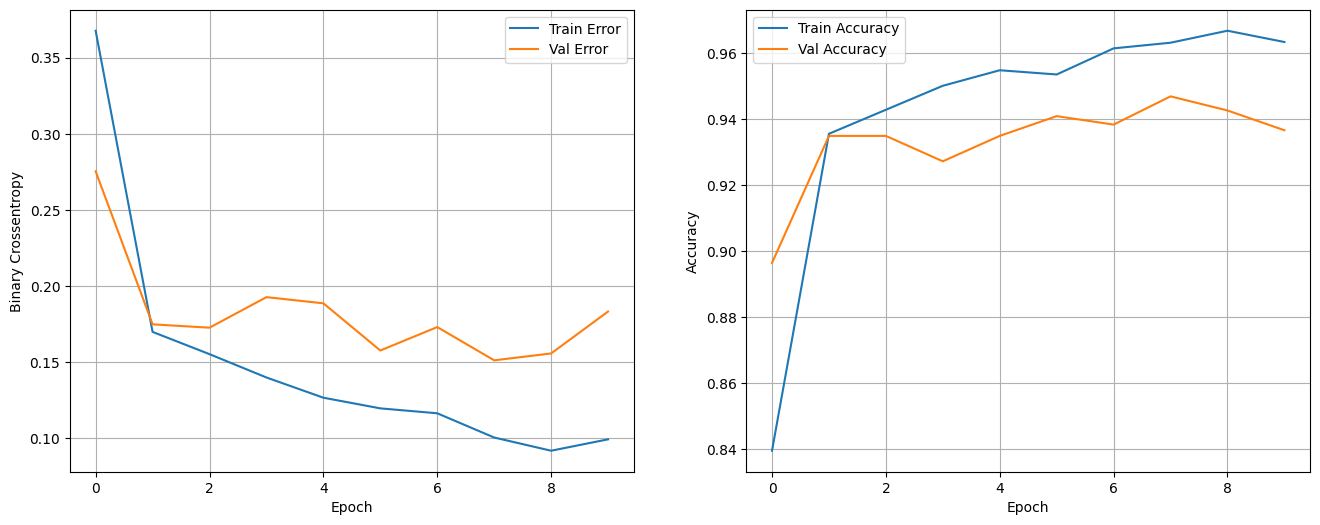

In [11]:
def show_loss_accuracy_evolution(history):

    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary Crossentropy')
    ax1.plot(hist['epoch'], hist['loss'], label='Train Error')
    ax1.plot(hist['epoch'], hist['val_loss'], label = 'Val Error')
    ax1.grid()
    ax1.legend()

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
    ax2.plot(hist['epoch'], hist['val_accuracy'], label = 'Val Accuracy')
    ax2.grid()
    ax2.legend()

    plt.show()

show_loss_accuracy_evolution(model_results)

In [12]:
 predictions = model.predict(x_test)
 y_predics = (predictions > 0.5).astype('int32')

print(confusion_matrix(y_test.argmax(axis=1), y_predics.argmax(axis=1)))
print(classification_report(y_test.argmax(axis=1), y_predics.argmax(axis=1)))

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step
[[280  21]
 [ 56 811]]
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       301
           1       0.97      0.94      0.95       867

    accuracy                           0.93      1168
   macro avg       0.90      0.93      0.92      1168
weighted avg       0.94      0.93      0.94      1168

